In [2]:
import seaborn as sns                                                                                                                                                
import matplotlib.pyplot as plt                                                                                                                                      
import pandas as pd
import numpy as np

In [3]:
%matplotlib inline
sns.set_context('poster')
sns.set_style('white')
sns.set_color_codes()

SIZE_DEFAULT=10
SIZE_LARGE=12

plt.rc("font", family="")
plt.rc("font", weight="normal")
plt.rc("font", size=SIZE_DEFAULT)
plt.rc("axes", titlesize=SIZE_LARGE)
plt.rc("axes", labelsize=SIZE_LARGE)
plt.rc("xtick", labelsize=SIZE_DEFAULT)
plt.rc("ytick", labelsize=SIZE_DEFAULT)
plt.rc("xtick.major", size=6, pad=2)
plt.rc("ytick.major", size=6, pad=2)
params = {'mathtext.default' : 'regular'}
plt.rcParams.update(params)

# RMSF

In [4]:
rmsf_skl = pd.read_csv("../sklearn_results/rmsf.dat", header = None, names = ["skl_rmsf"])
rmsf_gmx = pd.read_csv("../gmx_results/03_analysis/gmx_rmsf_noindex.xvg", header = None, names = ["gmx_rmsf"])

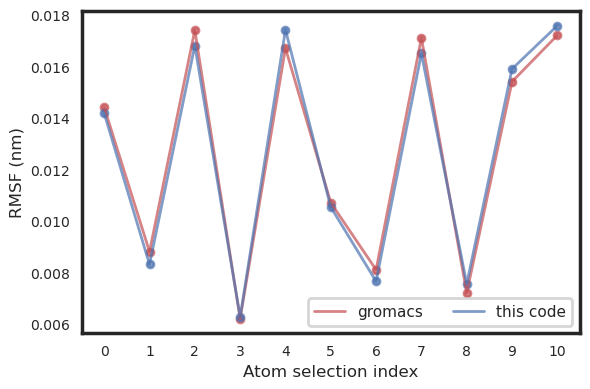

In [17]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))

x = np.arange(len(rmsf_gmx))

plt.plot(x, rmsf_gmx, lw=2, alpha=0.7, c='r', label='gromacs' )
plt.plot(x, rmsf_skl, lw=2, alpha=0.7, c='b', label='this code' )

plt.scatter(x, rmsf_gmx, alpha=0.7, s=25, c='r' )
plt.scatter(x, rmsf_skl, alpha=0.7, s=25, c='b' )

plt.legend(loc='lower right', fontsize=11, ncols = 2 )

plt.xlabel("Atom selection index")
plt.ylabel("RMSF (nm)")                                                                                                                                  
plt.xticks(x)  

plt.tight_layout()
plt.savefig('compare_rmsf.png', dpi=300)

# Variance

In [9]:
var_skl = pd.read_csv("../sklearn_results/eigenvalues.dat", skiprows=1, sep = "\t", names = ["n", "skl_var"])
var_gmx = pd.read_csv("../gmx_results/03_analysis/gmx_eigenvalues_noindex.dat", sep = "\s+", header = None, names = ["n", "gmx_var"])

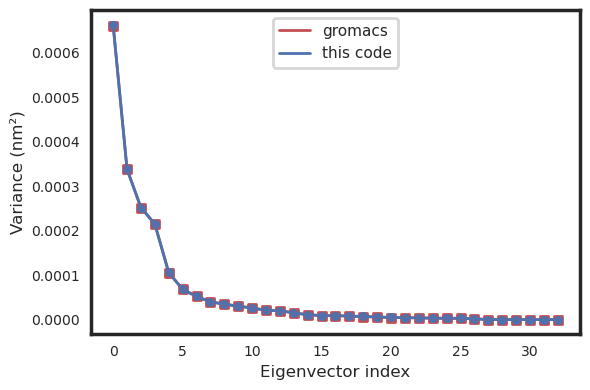

In [18]:
fig, ax = plt.subplots(1, 1, figsize=(6,4))

plt.plot(var_gmx["n"]-1, var_gmx["gmx_var"], lw=2, alpha=1, c='r', label='gromacs' )
plt.plot(var_skl["n"],   var_skl["skl_var"], lw=2, alpha=1, c='b', label='this code' )

plt.scatter(var_gmx["n"]-1, var_gmx["gmx_var"], alpha=1, s=30, c='r', marker='s' )
plt.scatter(var_skl["n"],   var_skl["skl_var"], alpha=1, s=20, c='b' )

plt.legend(loc='upper center', fontsize=11 )

plt.xlabel("Eigenvector index")
plt.ylabel("Variance (nm²)")     

plt.tight_layout()
plt.savefig('compare_variance.png', dpi=300)

# PC projections

In [19]:
pcs_skl = pd.read_csv("../sklearn_results/all_pcs.dat", skiprows=1, sep = "\t", names = ["t", "pc1", "pc2", "pc3"])
pcs_gmx = pd.read_csv("../gmx_results/03_analysis/all_pcs.dat", skiprows=1, sep = "\t", header = None, names = ["t", "pc1", "pc2", "pc3"])

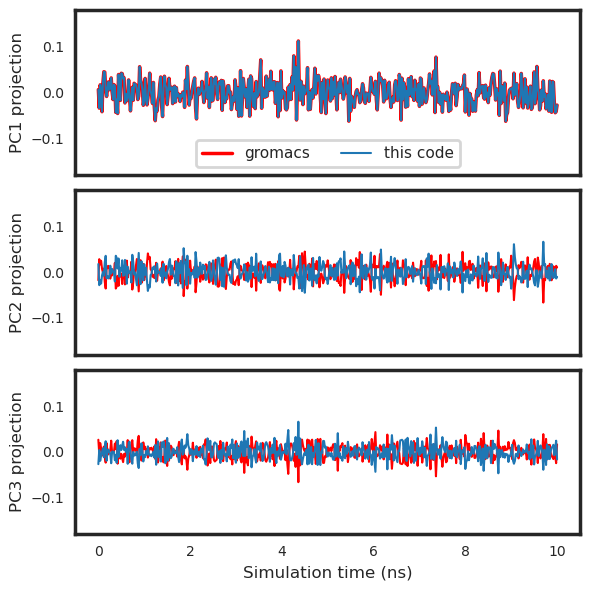

In [21]:
fig, ax = plt.subplots(3, 1, figsize=(6,6), sharex=True)

# ps to ns
ax[0].plot(pcs_gmx["t"]/1000, pcs_gmx["pc1"], lw=2.5, alpha=1, c='red', label='gromacs' )
ax[1].plot(pcs_gmx["t"]/1000, pcs_gmx["pc2"], lw=1.5, alpha=1, c='red', label='gromacs' )
ax[2].plot(pcs_gmx["t"]/1000, pcs_gmx["pc3"], lw=1.5, alpha=1, c='red', label='gromacs' )

# frame to ns
ax[0].plot(pcs_skl["t"]*20/1000, pcs_skl["pc1"], lw=1.5, alpha=1, label='this code' )
ax[1].plot(pcs_skl["t"]*20/1000, pcs_skl["pc2"], lw=1.5, alpha=1, label='this code' )
ax[2].plot(pcs_skl["t"]*20/1000, pcs_skl["pc3"], lw=1.5, alpha=1, label='this code' )

ax[0].legend(loc='lower center', fontsize=11, ncols = 2 )

plt.xlabel("Simulation time (ns)")
ax[0].set_ylim(-0.18, 0.18)
ax[1].set_ylim(-0.18, 0.18)
ax[2].set_ylim(-0.18, 0.18)

ax[0].set_yticks([-0.1, 0.0, 0.1])
ax[1].set_yticks([-0.1, 0.0, 0.1])
ax[2].set_yticks([-0.1, 0.0, 0.1])

ax[0].set_ylabel("PC1 projection") 
ax[1].set_ylabel("PC2 projection") 
ax[2].set_ylabel("PC3 projection") 

plt.tight_layout()
plt.savefig('compare_projections.png', dpi=300)